In [19]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv('converted_voltage_thickness.csv')
print(df.head())

   Voltage(V)  Thickness(nm)      Value
0         0.0            100  15.656240
1         0.0            200  18.372112
2         0.0            300  20.060791
3         0.0            400  21.146976
4         0.0            500  21.870996


In [6]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[: , :-1],df.iloc[: , -1],test_size=0.2,random_state=42)


In [ ]:
model = RandomForestRegressor(n_estimators = 20, random_state = 42,criterion = 'absolute_error')

In [15]:
def create_study(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_depth = trial.suggest_int('max_depth', 1, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, random_state=42)
    model.fit(X_train, y_train)
    res = model.predict(X_test)
    return mean_absolute_error(y_test, res)

study = optuna.create_study(direction='minimize')
study.optimize(create_study, n_trials=50)
print("Best hyperparameters: ", study.best_params)





[I 2026-03-27 12:47:42,820] A new study created in memory with name: no-name-9219e0dc-cf44-4697-8128-03d02d5abf9c
[I 2026-03-27 12:47:42,858] Trial 0 finished with value: 0.28363856398439186 and parameters: {'n_estimators': 18, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.28363856398439186.
[I 2026-03-27 12:47:42,917] Trial 1 finished with value: 1.624255963689083 and parameters: {'n_estimators': 34, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.28363856398439186.
[I 2026-03-27 12:47:42,960] Trial 2 finished with value: 2.8675229993927354 and parameters: {'n_estimators': 24, 'max_depth': 1, 'min_samples_split': 10, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.28363856398439186.
[I 2026-03-27 12:47:43,079] Trial 3 finished with value: 0.9615283839245503 and parameters: {'n_estimators': 61, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 

Best hyperparameters:  {'n_estimators': 86, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [34]:
resultant_model = RandomForestRegressor(**study.best_params, random_state=42)
resultant_model.fit(df.iloc[: , :-1], df.iloc[: , -1])
res = resultant_model.predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, res))
print("Mean Squared Error:", mean_squared_error(y_test, res))
print("R^2 Score:", r2_score(y_test, res))


Mean Absolute Error: 0.06549816860429161
Mean Squared Error: 0.0681590553293591
R^2 Score: 0.9987697458781473


In [35]:
res_train = model.predict(X_train)
print("Train Mean Absolute Error:", mean_absolute_error(y_train, res_train))
print("Train Mean Squared Error:", mean_squared_error(y_train, res_train))
print("Train R^2 Score:", r2_score(y_train, res_train))

Train Mean Absolute Error: 0.09293642154166677
Train Mean Squared Error: 0.17826858721199593
Train R^2 Score: 0.9928826380935533


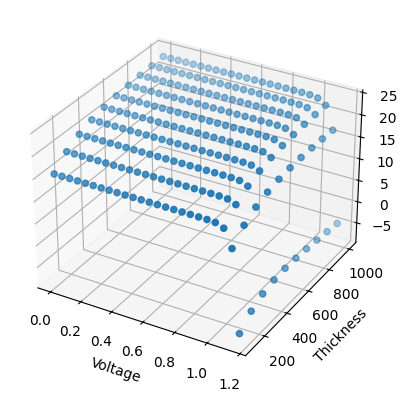

In [36]:
import matplotlib.pyplot as plt


x0_input = df['Voltage(V)'].to_numpy()
x1_input = df['Thickness(nm)'].to_numpy()
y_input = df['Value'].to_numpy()


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x0_input, x1_input, y_input)

ax.set_xlabel('Voltage')
ax.set_ylabel('Thickness')
ax.set_zlabel('Output')

plt.show()


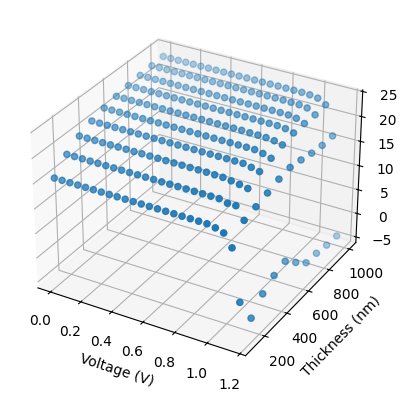

In [38]:
x = df['Voltage(V)'].to_numpy()
y = df['Thickness(nm)'].to_numpy()
z = model.predict(df[['Voltage(V)', 'Thickness(nm)']])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Thickness (nm)')
ax.set_zlabel('Value')

plt.show()

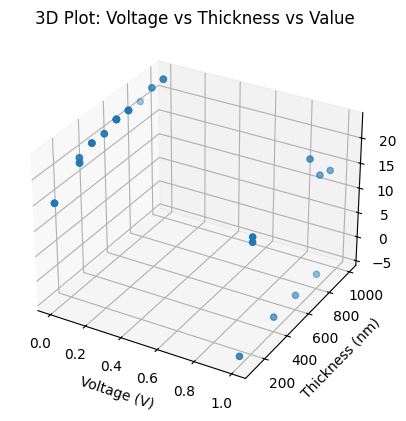

In [27]:
#just for testing the model on test data


x = X_test[['Voltage(V)']].to_numpy().flatten().astype(int)
y = X_test[['Thickness(nm)']].to_numpy().flatten().astype(int)
z = res.flatten().astype(int)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Thickness (nm)')
ax.set_zlabel('Value')

plt.title("3D Plot: Voltage vs Thickness vs Value")
plt.show()